In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

insurance=pd.read_csv("insurance.csv")

In [266]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [267]:
insurance.shape

(1338, 7)

In [268]:
insurance.dtypes


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [269]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Exploratory Data Analysis for the given dataset

In [270]:
print("number of datapoints: ",insurance.shape[0])
print("number of columns/fields: ",insurance.shape[1])

number of datapoints:  1338
number of columns/fields:  7


In [271]:
m=insurance.shape[0]
print("training examples: ",m)

training examples:  1338


In [272]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [273]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [274]:
insurance.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [275]:
# to check for missing values
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [276]:
# check for duplicate values
insurance.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [277]:
# check each column for empty strings
(insurance == "").sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [278]:
# to check unique values
insurance.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

The graph depects data is normally skewed to the right. which indicates that inorder to normalize this curve to correct centralized distribution, we have to apply log function

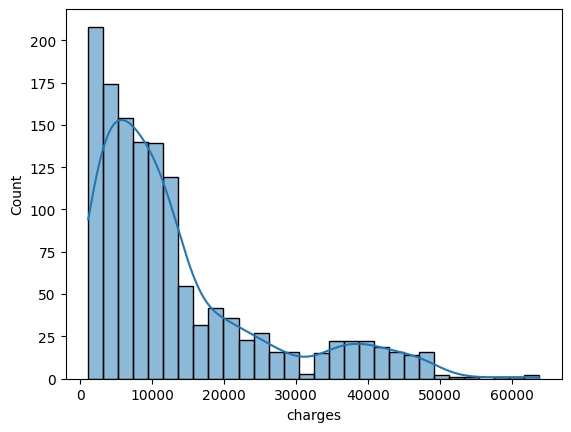

In [279]:
import seaborn as sns
import matplotlib.pyplot as plt
# to check how the datapoints are distributed if plotted against "charges"
sns.histplot(insurance["charges"], kde=True)
plt.show()

applied log transform on the target variable "charges" to normalize the right skewed distribution

Text(0.5, 1.0, 'log transformed with charges')

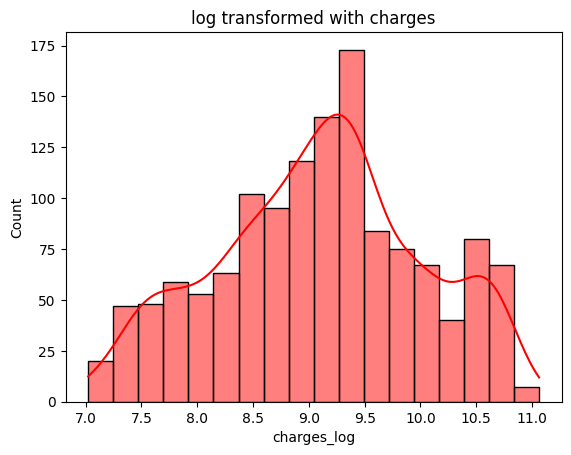

In [280]:
insurance["charges_log"]=np.log(insurance["charges"])
sns.histplot(insurance["charges_log"],kde=True,color="red")
plt.title("log transformed with charges")


In [281]:
# proportion for each column
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:")
    print(insurance[col].value_counts(normalize=True) * 100)


sex:
sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64

smoker:
smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64

region:
region
southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: proportion, dtype: float64


In [282]:
insurance = pd.get_dummies(insurance, columns=["sex", "smoker", "region"], drop_first=True)
print(insurance.columns)

Index(['age', 'bmi', 'children', 'charges', 'charges_log', 'sex_male',
       'smoker_yes', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')


adding an additional feature (bmi_smoker)

In [283]:
# adding an addtional feature
insurance["bmi_smoker"] = insurance["bmi"] * insurance["smoker_yes"]

x = insurance[["age", "bmi", "smoker_yes", "bmi_smoker"]].values.astype(float)

Training a model

TRAIN/TEST DATA SPLIT

In [284]:
# splitting the original dataset into train and test data
import numpy as np
x = insurance[["age", "bmi", "smoker_yes","children"]].values.astype(float)
y = insurance["charges_log"].values.astype(float)

# random shuffle of indices
np.random.seed(40)
indices=np.random.permutation(len(x))

# split the data in 70:30 
split=int(0.8*len(x))
x_train,x_test=x[indices[:split]],x[indices[split:]]
y_train,y_test=y[indices[:split]],y[indices[split:]]

print(f"Training samples: {len(x_train)}")
print(f"Testing samples:  {len(x_test)}")

Training samples: 1070
Testing samples:  268


Feature Scaling

In [285]:
# z-score normalized scaling 
mean_x = x_train.mean(axis=0)
std_x = x_train.std(axis=0)

mean_y=y_train.mean(axis=0)
std_y=y_train.std(axis=0)


In [286]:
# z-scores for the following datapoints

x_train_scaled=(x_train-mean_x)/std_x
x_test_scaled=(x_test - mean_x)/std_x  


Multiple Linear Regression Model 



charges_log=b + (w1 x age) +(w2 x bmi) + (w3 x smoker) +(w4 x bmi_smoker)

In [287]:
# for age only
mean_x = x_train[:, 0].mean()
mean_y = y_train.mean()

numerator   = ((x_train[:, 0] - mean_x) * (y_train - mean_y)).sum()
denominator = ((x_train[:, 0] - mean_x) ** 2).sum()

w = numerator/denominator
b = mean_y-(w * mean_x)

Vectorized form

y_predictions = (x_train).w 

In [288]:
# adding bias column
x_train_b=np.c_[np.ones(len(x_train_scaled)),x_train_scaled]
x_test_b=np.c_[np.ones(len(x_test_scaled)),x_test_scaled]

# initializing the bias column
w = np.zeros(x_train_b.shape[1])

# parameters
alpha=0.1 #learning rate
iterations=9900#no. of iterations 
m= len(x_train) #number of training examples

# gradient descent
for iter in range(iterations):
    y_predictions=x_train_b @ w #y=w.x
    error=y_predictions-y_train   #error=predicted-actual value
    grad=(1/m)*x_train_b.T @ error   #gradient descent
    w=w-alpha*grad #updating the weights

# printing the final weights of all features necessary (age,bmi,smoker)
print(f"\nbias (b):{w[0]:.2f}")
print(f"w_age:{w[1]:.2f}")
print(f"w_bmi: {w[2]:.2f}")
print(f"w_smoker: {w[3]:.2f}")


bias (b):9.08
w_age:0.48
w_bmi: 0.07
w_smoker: 0.63


In [289]:
# prediction over the test data
y_pred_log=x_test_b @ w  #weights

In [290]:
# convert back from log scale in order to evaluate in actual values
y_pred_actual=np.exp(y_pred_log)
y_test_actual=np.exp(y_test)

In [295]:

# MSE in log scale
mse_log = np.mean((y_test - y_pred_log) ** 2)

# R² in log scale
ss_res  = np.sum((y_test - y_pred_log) ** 2)
ss_tot  = np.sum((y_test - y_test.mean()) ** 2)
r2_log  = 1 - (ss_res / ss_tot)

print(f"MSE (log scale): {mse_log:.4f}")
print(f"R²  (log scale): {r2_log:.4f}")

MSE (log scale): 0.2087
R²  (log scale): 0.7547
